# 6. Baseline Modeling

## Objective

This notebook establishes baseline performance for the credit default
classification problem.

Two baseline models are evaluated:

1. Dummy Classifier
2. Logistic Regression

The models are evaluated on the validation set using multiple classification
metrics.

The test set remains untouched and will only be used after the final model
and decision threshold have been selected.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
df = pd.read_csv(
    "../data/processed/credit_default_features.csv"
)

df.shape

(30000, 37)

In [3]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,RECENT_DELAY,AVG_BILL_AMT,MAX_BILL_AMT,AVG_PAY_AMT,TOTAL_PAY_AMT,ZERO_PAYMENT_MONTHS,CREDIT_UTILIZATION,AVG_CREDIT_UTILIZATION,PAYMENT_TO_BILL_RATIO,BILL_CHANGE
0,20000,2,2,1,24,2,2,-1,-1,-2,...,1,1284.000000,3913,114.833333,689,5,0.195650,0.064200,0.089434,3913
1,120000,2,2,2,26,-1,2,0,0,0,...,0,2846.166667,3455,833.333333,5000,2,0.022350,0.023718,0.292791,-579
2,90000,2,2,2,34,0,0,0,0,0,...,0,16942.166667,29239,1836.333333,11018,0,0.324878,0.188246,0.108388,13690
3,50000,2,2,1,37,0,0,0,0,0,...,0,38555.666667,49291,1398.000000,8388,0,0.939800,0.771113,0.036259,17443
4,50000,1,2,1,57,-1,0,-1,0,0,...,0,18223.166667,35835,9841.500000,59049,0,0.172340,0.364463,0.540054,-10514


In [4]:
X = df.drop(columns=["DEFAULT_PAYMENT_NEXT_MONTH"])
y = df["DEFAULT_PAYMENT_NEXT_MONTH"]

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [6]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (21000, 36)
Validation: (4500, 36)
Test: (4500, 36)


In [7]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

In [8]:
numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

In [9]:
numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [10]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [11]:
def evaluate_model(model, X_data, y_true, model_name):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        )
    }

    return results

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [14]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

In [15]:
dummy_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [16]:
dummy_results = evaluate_model(
    dummy_pipeline,
    X_val,
    y_val,
    "Dummy Classifier"
)

dummy_results

{'Model': 'Dummy Classifier',
 'Accuracy': 0.7788888888888889,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': 0.5,
 'PR_AUC': 0.22111111111111112}

### Dummy Classifier - Findings

The Dummy Classifier predicts the majority class for every observation.

Although the model may achieve relatively high accuracy because most
customers do not default, it fails to identify customers who actually default.

This demonstrates why accuracy alone is not an appropriate metric for
this classification problem.

In [17]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [18]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [19]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_val,
    y_val,
    "Logistic Regression"
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8097777777777778,
 'Precision': 0.643298969072165,
 'Recall': 0.3135678391959799,
 'F1': 0.42162162162162165,
 'ROC_AUC': 0.7556263485759754,
 'PR_AUC': 0.5108967620561805}

In [20]:
#Logistic Regression: class_weight='balanced'
logistic_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_balanced_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [21]:
logistic_balanced_results = evaluate_model(
    logistic_balanced_pipeline,
    X_val,
    y_val,
    "Logistic Regression (Balanced)"
)

In [22]:
results_df = pd.DataFrame([
    dummy_results,
    logistic_results,
    logistic_balanced_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Classifier,0.778889,0.000000,0.000000,0.000000,0.500000,0.221111
1,Logistic Regression,0.809778,0.643299,0.313568,0.421622,0.755626,0.510897
2,Logistic Regression (Balanced),0.746444,0.445522,0.600000,0.511349,0.760086,0.508136


## Baseline Model Comparison

Logistic Regression is compared with the Dummy Classifier to determine
whether the available customer and repayment features provide predictive
information beyond simply predicting the majority class.

Particular attention is given to Recall, F1-score, ROC-AUC, and PR-AUC
because the target variable is moderately imbalanced.

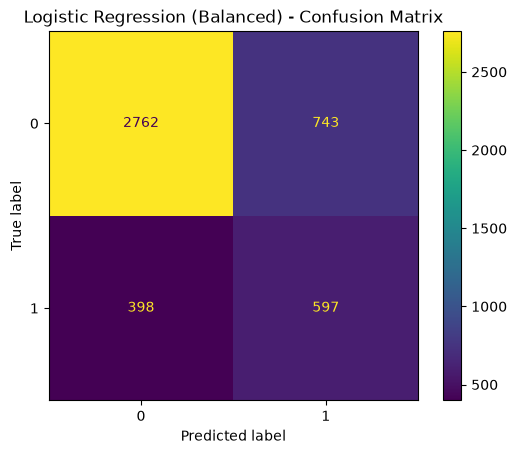

True Negative : 2762
False Positive: 743
False Negative: 398
True Positive : 597


In [23]:
y_val_balanced_pred = logistic_balanced_pipeline.predict(X_val)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_balanced_pred
)
plt.title("Logistic Regression (Balanced) - Confusion Matrix")
plt.show()

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_val, y_val_balanced_pred).ravel()
print(f"True Negative : {tn_b}")
print(f"False Positive: {fp_b}")
print(f"False Negative: {fn_b}")
print(f"True Positive : {tp_b}")


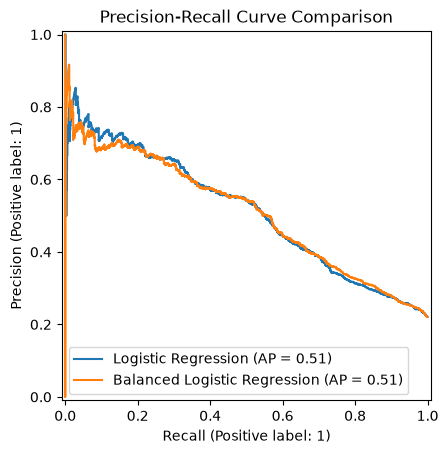

In [24]:
ax = plt.gca()

PrecisionRecallDisplay.from_estimator(
    logistic_pipeline,
    X_val,
    y_val,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_estimator(
    logistic_balanced_pipeline,
    X_val,
    y_val,
    name="Balanced Logistic Regression",
    ax=ax
)

plt.title("Precision-Recall Curve Comparison")
plt.show()

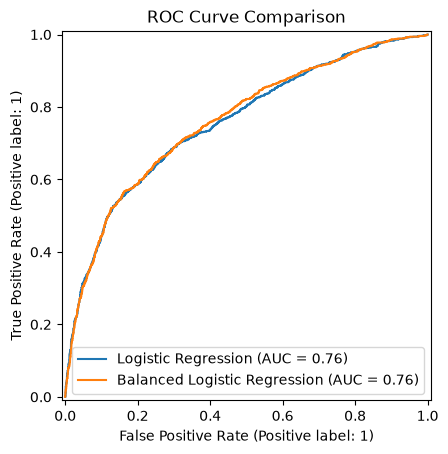

In [25]:
ax = plt.gca()

RocCurveDisplay.from_estimator(
    logistic_pipeline,
    X_val,
    y_val,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_estimator(
    logistic_balanced_pipeline,
    X_val,
    y_val,
    name="Balanced Logistic Regression",
    ax=ax
)

plt.title("ROC Curve Comparison")
plt.show()

In [26]:
import os
os.makedirs("../reports", exist_ok=True)
results_df.to_csv("../reports/baseline_results.csv", index=False)
print("Đã lưu bảng baseline vào: ../reports/baseline_results.csv")

Đã lưu bảng baseline vào: ../reports/baseline_results.csv


### Class Weight Experiment - Findings

Using `class_weight="balanced"` significantly improved the model's ability
to identify customers who default.

- Recall increased from approximately 31.36% to 60.00%.
- F1-score increased from approximately 42.16% to 51.13%.
- Precision decreased from approximately 64.33% to 44.55%.
- Accuracy decreased from approximately 80.98% to 74.64%.

The balanced model detects substantially more default customers, but this
comes at the cost of more false-positive predictions.

This trade-off is important in credit risk modeling because missing a
high-risk customer may be more costly than incorrectly flagging a
non-default customer for further review.